# Functions

In [1]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest
import warnings
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)


#warnings.simplefilter(action="default", category=RuntimeWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 37.00it/s]

Numba compilation complete!


In [ ]:
def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.mean_diff.results['test'], test.mean_diff.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def meandiffchart(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst, ci=90)    
    tab = pd.concat([test.mean_diff.results['test'], round(test.mean_diff.results['difference'],3)], axis = 1)
    tab.rename(columns = {'test':'MBON', 'difference':parameter}, inplace = True)

    return tab

# Code

In [4]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = labcomp

root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_test\\"

In [ ]:
respondertype = "ACR"
filepath = root + respondertype + " 20250114_compilation_full.csv"
df2= pd.read_csv(filepath)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [ ]:
dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
dfspeed, notsortedlist, notdabestlist = chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')

In [ ]:
valencemd = meandiffchart(dfi, sortedlist, 'pi_smoothed_Pattern 01')
srmd = meandiffchart(dfi, sortedlist, 'log2_speed_ratio_Pattern 01')

totalmd = pd.DataFrame()
totalmd = pd.concat([valencemd,srmd.iloc[:,1]], axis = 1)
totalmd.rename(columns = {'MBON': 'MBON > ' + respondertype, 'pi_smoothed_Pattern 01':'PI MeanDiff', 'log2_speed_ratio_Pattern 01':'Speed Ratio MeanDiff'}, inplace = True)

# totalmd.MBON = totalmd.MBON.astype("category")
# totalmd.MBON = totalmd.MBON.cat.set_categories(arrangedsorting['test'])

# totalmd = totalmd.sort_values(["MBON"]).reset_index(drop=True)

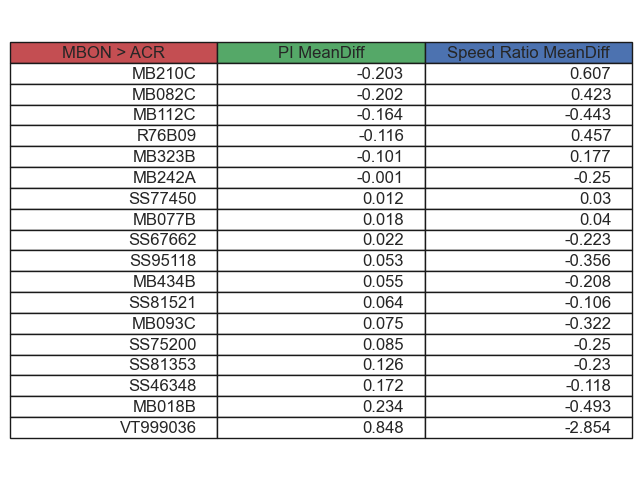

In [ ]:
fig, ax = plt.subplots()

# hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

df = pd.DataFrame(np.random.randn(5, 4), columns=list('ABCD'))

tablele = ax.table(cellText= totalmd.values, colLabels=totalmd.columns, colColours = 'rgba(128,128,128,0.3)', loc='center')

fig.tight_layout()
#tablele.scale(2, 2)
tablele.set_fontsize(16)

plt.show()

#fig.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2024images\\" + date + "tableofOSAR" + genot + "values.png")

In [ ]:
reglst=[]

for name in totalmd['MBON'].tolist():

    dfo=dfi[dfi['MBON']==name]
    x = dfo['log2_speed_ratio_Pattern 01'].to_numpy()
    y = dfo['pi_smoothed_Pattern 01'].to_numpy()

    finiteMask = np.isfinite([x, y]).all(axis=0)

    corr = sp.stats.linregress(x[finiteMask], y[finiteMask])
    r2 = np.round(corr.rvalue**2, 3)
    
    reglst.append(r2)

reg = pd.DataFrame()
reg['MBON']=totalmd['MBON'].tolist()
reg["Regression value"] = reglst


totalmdt = pd.DataFrame()
totalmdt = pd.concat([totalmd, reg["Regression value"]], axis=1)
totalmdt.set_index('MBON', inplace = True)

## single lin regression

In [ ]:
import seaborn as sns

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full') & (df2['status'] == 'Offspring')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

nama = basegenotype

dfx = pd.DataFrame()

for each in nama:
    dfy = dfi[(dfi['MBON'] == each)]
    dfx = pd.concat([dfx, dfy])
    
osar_data = dfx

c:\Users\user\anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


Text(0.5, 0, 'Absolute PI Mean Diff')

<Figure size 2000x2000 with 0 Axes>

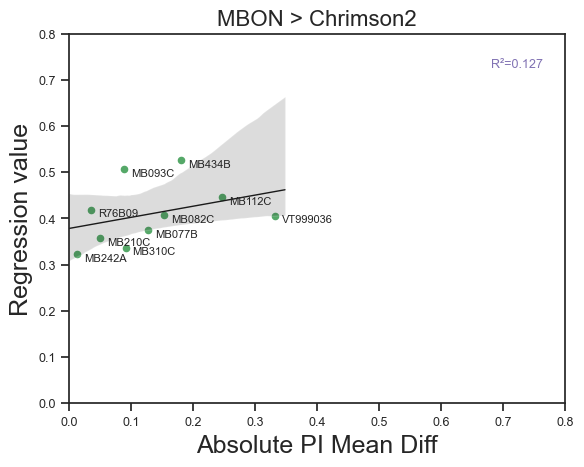

In [ ]:
totalmdtabs = totalmdt.copy().reset_index(drop=False)
totalmdtabs['PI MeanDiff'] = abs(totalmdtabs['PI MeanDiff'])

plt_1 = plt.figure(figsize=(20, 20), dpi = 100)

plt_1= totalmdtabs.plot(kind = 'scatter', x= 'PI MeanDiff', y = 'Regression value', color = "g");

sns.regplot(x = totalmdtabs['PI MeanDiff'],
                y = totalmdtabs['Regression value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                truncate=False)

x = totalmdtabs['PI MeanDiff'].to_numpy()
y = totalmdtabs['Regression value'].to_numpy()

finiteMask = np.isfinite([x, y]).all(axis=0)

corr = sp.stats.linregress(x[finiteMask], y[finiteMask])
lowers, uppers = skb.ci((x[finiteMask], y[finiteMask]), 
                        statfunction=r2_and_slope, 
                        n_samples=3000)

r2 = np.round(corr.rvalue**2, 3)
r2_lower = np.round(lowers[0], 3)
r2_upper = np.round(uppers[0], 3)

plt_1.annotate('R\u00b2='+str("{:.3f}".format(r2)), 
                        xy=(0.85, 0.90),  # xy coords
                        xycoords='axes fraction',
                        ha='left', va='bottom', color = "m",
                        fontsize=9)


for idx, row in totalmdtabs.iterrows():
    plt_1.annotate(row['MBON' ], (row['PI MeanDiff'], row['Regression value']), xytext=(5,-5),
                textcoords='offset points', family='sans-serif', fontsize=8)
plt_1.set_xlim(0, 0.8)
plt_1.set_ylim(0, 0.8)
plt_1.tick_params(axis='x', labelsize=9)
plt_1.tick_params(axis='y', labelsize=9)
plt_1.set_title("MBON > " + respondertype, fontsize = 16)
plt_1.set_xlabel('Absolute PI Mean Diff')

## total regression plot

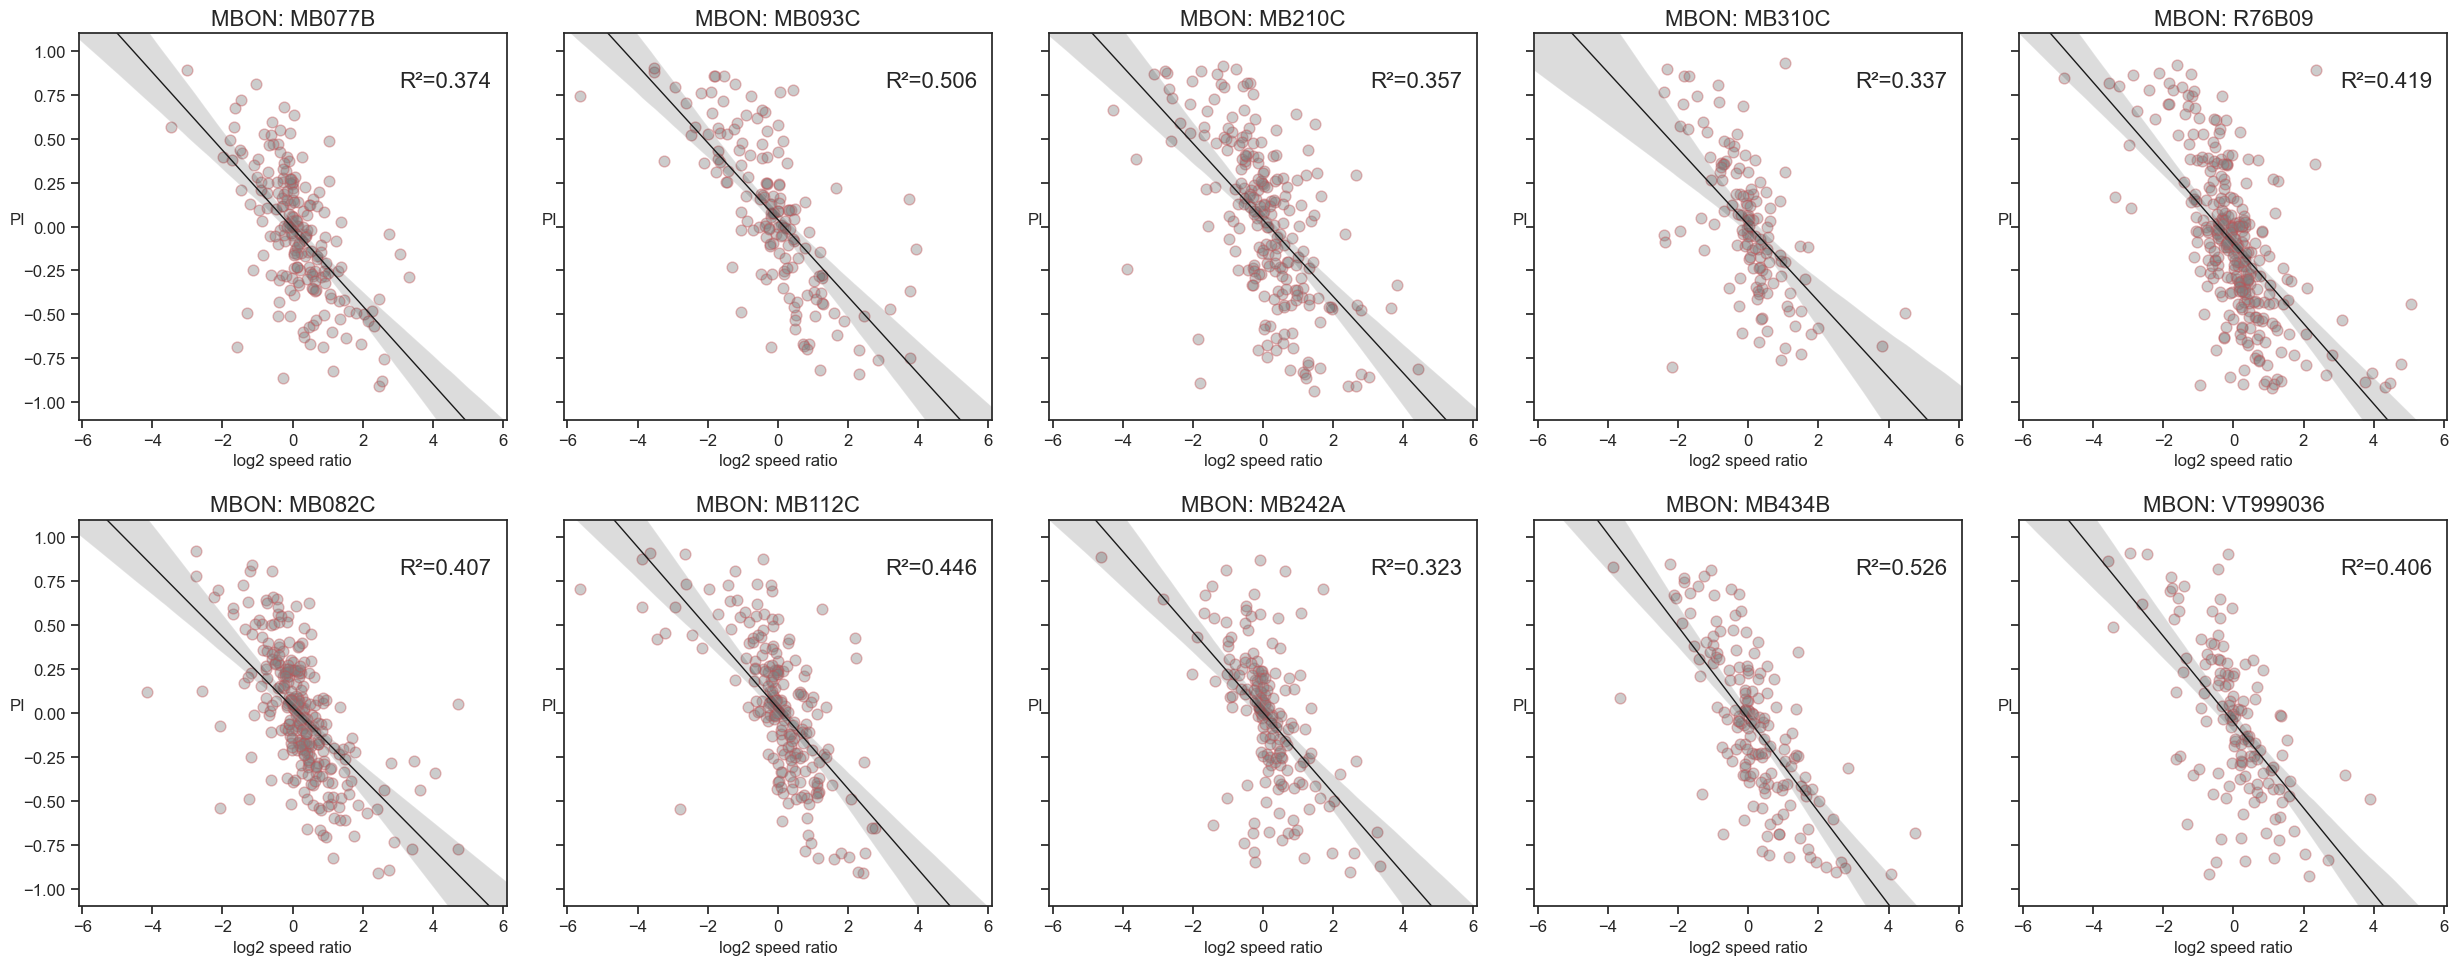

In [ ]:
f, ax = plt.subplots(nrows=2, ncols=5,figsize=(25,10), sharey = True)  #ACR

for name, row, col in zip(basegenotype, 5*[0,1], 2*[0]+2*[1]+2*[2]+2*[3]+2*[4]+2*[5]): #ACR

    df=osar_data[osar_data['MBON']==name]

    ax[row][col].set_ylim(-1.1,1.1)  
    ax[row][col].set_xlim(-6.1,6.1) 
    ax[row][col].tick_params(axis='x', labelsize= 12)
    ax[row][col].tick_params(axis='y', labelsize= 12)

    ax[row][col].scatter(df['log2_speed_ratio_Pattern 01'], 
            df['pi_smoothed_Pattern 01'],
            color='grey',
            edgecolors="r",
            alpha=0.4, 
            s=60)

                    
    sns.regplot(x = df['log2_speed_ratio_Pattern 01'],
                    y = df['pi_smoothed_Pattern 01'],
                    scatter=False,
                    line_kws={'lw':1}, 
                    color="k",
                    ax=ax[row][col],
                    truncate=False)

    x = df['log2_speed_ratio_Pattern 01'].to_numpy()
    y = df['pi_smoothed_Pattern 01'].to_numpy()

    finiteMask = np.isfinite([x, y]).all(axis=0)

    corr = sp.stats.linregress(x[finiteMask], y[finiteMask])
    lowers, uppers = skb.ci((x[finiteMask], y[finiteMask]), 
                            statfunction=r2_and_slope, 
                            n_samples=3000)

    r2 = np.round(corr.rvalue**2, 3)
    r2_lower = np.round(lowers[0], 3)
    r2_upper = np.round(uppers[0], 3)

    ax[row][col].annotate('R\u00b2='+str("{:.3f}".format(r2)), 
                            xy=(0.75, 0.85),  # xy coords
                            xycoords='axes fraction',
                            ha='left', va='bottom',
                            fontsize=16)


    ax[row][col].set_ylabel('PI', rotation = 0, fontsize=12)
    ax[row][col].set_xlabel('log2 speed ratio', fontsize=12)
    ax[row][col].set_title("MBON: "+ name, fontsize = 16)


f.tight_layout()

#f.savefig("D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\osar_test\\Figure\\regressionhalffull" + date + ".png")